In [159]:
import numpy as np
import matplotlib.pyplot as plt

In [160]:
def lorenz(T=300, dt=0.01, sigma=10, rho=28, beta=8/3):
    x, y, z = 1.0, 1.0, 1.0
    data = []

    for _ in range(T):
        dx = sigma * (y - x)
        dy = x * (rho - z) - y
        dz = x * y - beta * z

        x += dx * dt
        y += dy * dt
        z += dz * dt

        data.append([x, y, z])

    return np.array(data)

In [161]:
data = lorenz()
print(data.shape)
print(data[:3])

(300, 3)
[[1.         1.26       0.98333333]
 [1.026      1.51756667 0.96971111]
 [1.07515667 1.77972176 0.95942238]]


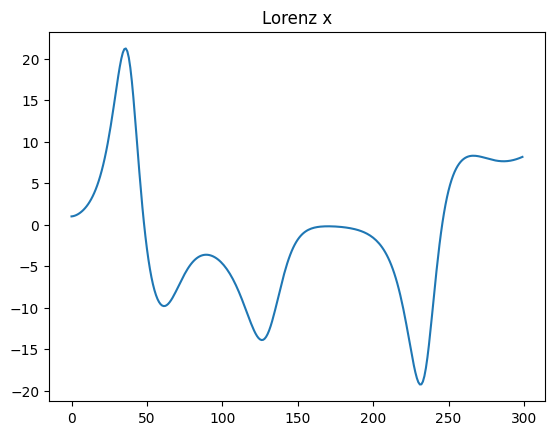

In [162]:
plt.plot(data[:, 0])
plt.title("Lorenz x")
plt.show()

In [163]:
N = 50
W = np.random.randn(N, N) * 0.1
Win = np.random.randn(N, 3) * 0.1

In [164]:
def step(x, u):
    return np.tanh(W @ x + Win @ u)

In [165]:
X = np.zeros((len(data), N))
x = np.zeros(N)

In [166]:
for t in range(len(data)):
    x = step(x, data[t])
    X[t] = x

In [167]:
print(X.shape)
print(X[:2, :5])

(300, 50)
[[ 0.07180419  0.03195591  0.0553826  -0.13566256 -0.20035089]
 [ 0.14409737 -0.14984507  0.14896738 -0.01029475 -0.24914764]]


In [168]:
from sklearn.linear_model import Ridge

In [169]:
X_train = X[:-1]
Y_train = data[1:]

In [170]:
model = Ridge(alpha=1.0)
model.fit(X_train, Y_train)
print("training done")

training done


In [171]:
preds = []
x = X[0].copy()
u = data[0].copy()

In [172]:
for _ in range(100):
    x = step(x, u)
    u = model.predict(x.reshape(1, -1))[0]
    preds.append(u)

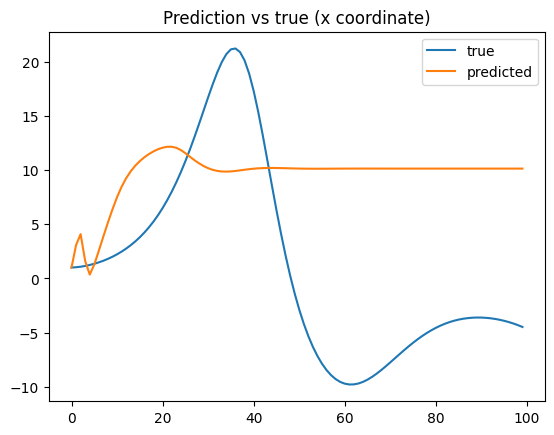

In [174]:
plt.plot(data[:100, 0], label="true")
plt.plot(preds[:, 0], label="predicted")
plt.legend()
plt.title("Prediction vs true (x coordinate)")
plt.show()

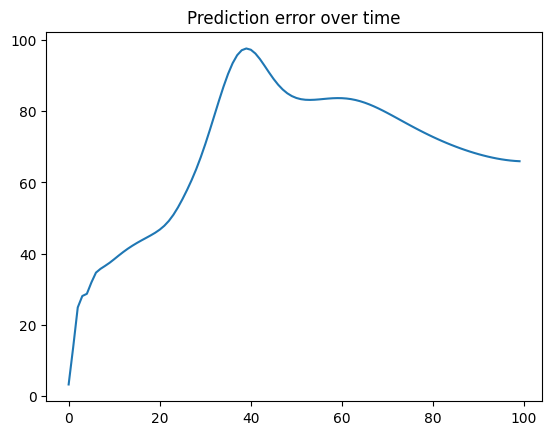

In [175]:
error = np.linalg.norm(data[:100] - preds, axis=1)
plt.plot(error)
plt.title("Prediction error over time")
plt.show()

In [176]:
print("Done. Now write 1 sentence describing whether prediction stays close or diverges.")

Done. Now write 1 sentence describing whether prediction stays close or diverges.
